In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../pyCudaPolygon"))
import pyCudaPolygon as pcp
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
from pyCudaPolygonLink import libpyCudaPolygon as lpcp

In [2]:
maxSteps = 1000

In [3]:
numPolygons = 32
n = 32
i = 5
phi = 0.05
kappa = 3.7
m = pcp.model(size = n * numPolygons, seed = i)

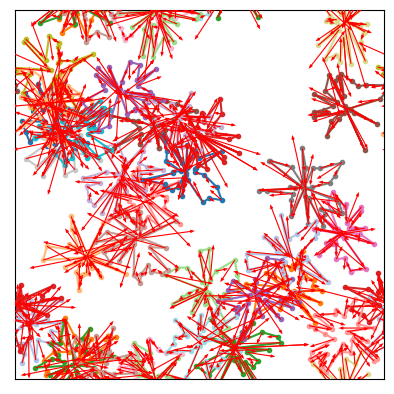

In [4]:
numPolygons = 32
n = 32
i = 5
phi = 0.05
kappa = 3.7
m = pcp.model(size = n * numPolygons, seed = i)
m.setModelEnum("softBody")

m.generateRandomPolygons(numPolygons, n)
m.setBiPerimeters(kappa)
m.setStiffness(1)
m.setCompressibility(1)

m.initializeNeighborCells()
m.updateNeighborCells()
m.updateNeighbors()
m.updateOutersections()
m.updateForceEnergy()
artists = m.draw(forces = m.getForces())

In [5]:
m.getEnergy()

1.080701970767497

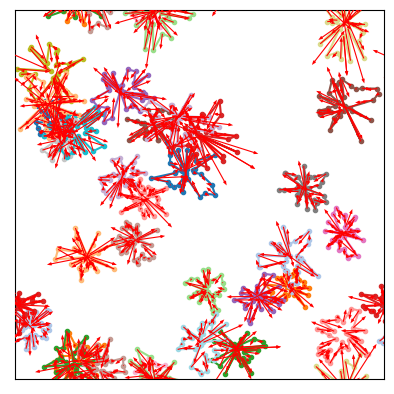

In [6]:
m.resetAreas()
m.updatePolygonGeometry()
areas = m.getAreas()
m.initializeNeighborCells()
m.updateNeighborCells()
m.updateNeighbors()
m.updateOutersections()
m.updateForceEnergy()
m.setModelEnum("softBody")
force = m.getForces()
artists = m.draw(forces = m.getForces())
m.updateForceEnergy()

In [7]:
m.setModelEnum("softBody")
m.minimizeGD(dt = 0.1, maxSteps = maxSteps, progressBar = True)

Processing: 100%|█████████████████████| 1000/1000 [00:00<00:00, 1830.78it/s]

0.0 0.0 0


(3.663832006549968e-06, 0.38980671633732855, array([0., 0., 0.]))

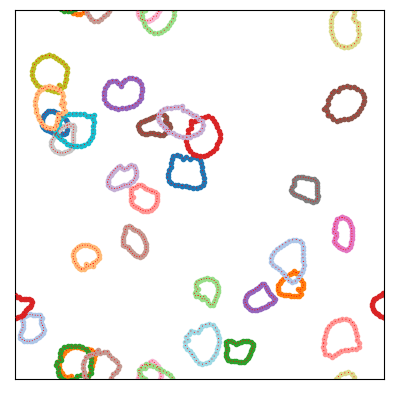

In [8]:
m.initializeNeighborCells()
m.updateNeighborCells()
m.updateNeighbors()
m.updateOutersections()
m.updateForceEnergy()
force = m.getForces()
_ = m.draw(forces = force)

In [9]:
m.getMaxUnbalancedForce()

1.1699445848920909e-05

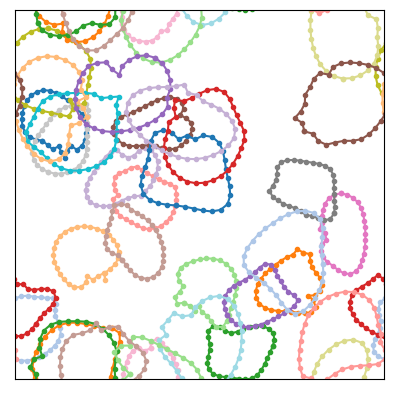

In [10]:
phi = 1.0
m.setPhi(phi)
_ = m.draw()

In [11]:
m.updatePolygonGeometry()
print(m.getConstraintViolation())

[3.78784806e-15 5.20064683e-02 5.20031722e-02]


In [12]:
m.saveModel("LMTesting", overwrite = True)

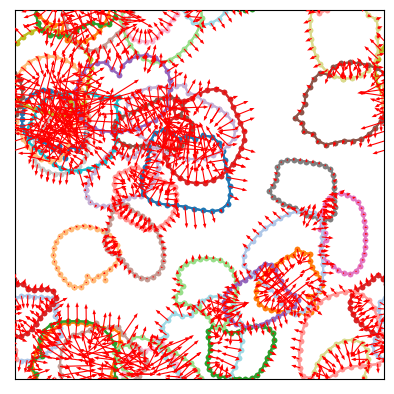

In [13]:
m.setModelEnum("normal")
m.initializeNeighborCells()
m.updateNeighborCells()
m.updateNeighbors()
m.updateOutersections()
m.updateForceEnergy()
force = m.getForces()
m.projectForce()
fig, ax = plt.subplots()
_ = m.draw(ax = ax, forces = force)
forces = m.getForces()
_ = m.draw(ax = ax, forces = forces)

Processing: 100%|████████████████████████████| 1/1 [00:00<00:00, 415.40it/s]


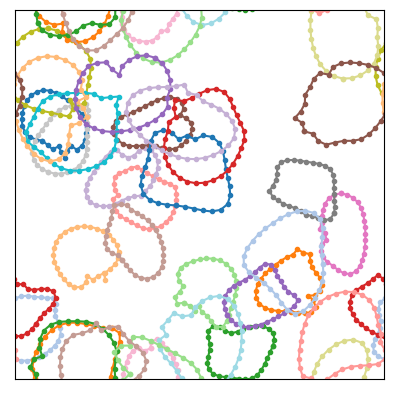

In [14]:
m.setModelEnum("normal")
m.minimizeGD(dt = 1e-6, maxSteps = 0, progressBar = True, nIter = 1000)
_ = m.draw()
plt.show()

In [15]:
m.updatePolygonGeometry()
print(m.getConstraintViolation())

[3.78784806e-15 5.20064683e-02 5.20031722e-02]


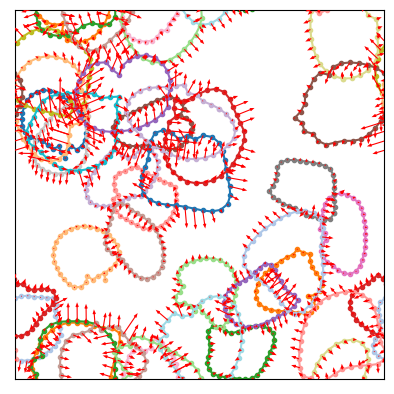

In [16]:
m.setModelEnum("normal")
m.updateNeighborCells()
m.updateNeighbors()
m.updateOutersections()
m.updateForceEnergy()
m.projectForce()
artists = m.draw(forces = m.getForces(), arrowColor = 'r')

Processing: 100%|█████████████████████████████| 1/1 [00:00<00:00,  7.75it/s]


1000.0 1000.0 1000


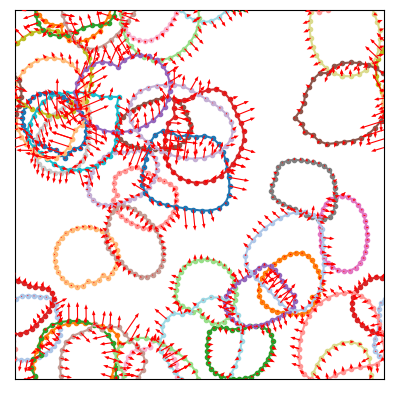

In [17]:
#for dt in np.logspace(-6, -3, 10):
#    m.setModelEnum("edgeOnly")
#    m.minimizeGD(dt = dt, maxSteps = maxSteps, progressBar = True)
m.setModelEnum("normal")
m.minimizeGD(dt = 1e-5, maxSteps = 1, progressBar = True, nIter = 1000)
_ = m.draw(forces = m.getForces())
plt.show()

In [18]:
m.getMaxUnbalancedForce(), m.getEnergy(), m.getConstraintViolation()

(0.10286407735099848,
 0.4748540931440575,
 array([2.10768831e-15, 6.68397838e-07, 4.78399314e-07]))

In [19]:
#m.xpbdProject(nIter = 100)

In [20]:
m.updatePolygonGeometry()

In [21]:
m.getMaxUnbalancedForce(), m.getEnergy(), m.getConstraintViolation()

(0.10286407735099848,
 0.4748540931440575,
 array([2.10768831e-15, 6.68397838e-07, 4.78399314e-07]))

In [22]:
m.setModelEnum("softBody")
m.minimizeGD(dt = 0.1, maxSteps = maxSteps, progressBar = True)

Processing: 100%|█████████████████████| 1000/1000 [00:00<00:00, 1820.45it/s]

0.0 0.0 0


(9.307684668473661e-16, 1, array([0., 0., 0.]))

Processing: 100%|█████████████████████████████| 1/1 [00:00<00:00,  8.09it/s]


1000.0 1000.0 1000


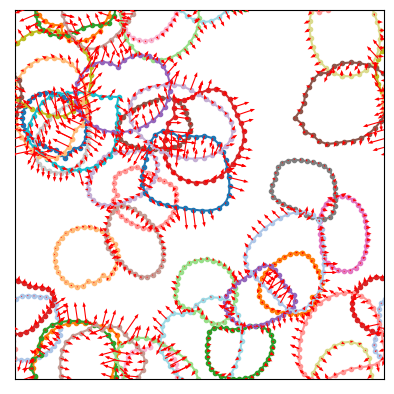

In [23]:
m.setModelEnum("normal")
m.minimizeGD(dt = 1e-4, maxSteps = 1, progressBar = True, nIter = 1000)
_ = m.draw(forces = m.getForces())
plt.show()

In [24]:
m.getMaxUnbalancedForce(), m.getEnergy(), m.getConstraintViolation()

(0.08545035001161977,
 0.4794282372512099,
 array([2.11498579e-15, 5.22611207e-11, 3.74170116e-11]))

In [25]:
m.getMaxEffectiveForce(1)

0.08605118331424165

In [39]:
def resetMinimizeGD(model, maxConstraintViolationThreshold = 0.02, maxSteps = -1):
    trials = 20
    trial = 0
    dtNew = 1e-4
    while trial < trials:
#        model.setModelEnum("softBody")
#        model.minimizeGD(dt = dtNew, maxConstraintViolationThreshold = maxConstraintViolationThreshold, maxSteps = 1e6, progressBar = True, nIter = 0)
        model.setModelEnum("normal")
        energy, dtNew, iterStatistics = model.minimizeGD(dt = 1e-3, maxConstraintViolationThreshold = 1, maxSteps = maxSteps, progressBar = True, nIter = 0)
        energy, dtNew, iterStatistics = model.minimizeGD(dt = 1e-3, maxConstraintViolationThreshold = 1, maxSteps = 1, progressBar = True, nIter = 0)
        print(energy, model.getMaxUnbalancedForce())
        trial += 1
        print(trial)
#    model.setModelEnum("softBody")
#    model.minimizeGD(dt = 0.1, maxConstraintViolationThreshold = maxConstraintViolationThreshold, maxSteps = 1e6, progressBar = False)

In [40]:
for i in range(100):
    resetMinimizeGD(m, maxSteps = 10000)

Processing: 100%|████████████████████| 10000/10000 [01:36<00:00, 103.67it/s]


0.0 0.0 0


Processing: 100%|█████████████████████████████| 1/1 [00:00<00:00, 88.85it/s]


0.0 0.0 0
0.010440613071022705 0.0037141363963682033
1


Processing: 100%|████████████████████| 10000/10000 [01:36<00:00, 103.69it/s]


...

0.0 0.0 0


Processing: 100%|█████████████████████████████| 1/1 [00:00<00:00, 93.57it/s]


0.0 0.0 0
0.01043971405109253 0.0030795826728708
4


Processing:  12%|██▌                  | 1239/10000 [00:12<01:26, 101.79it/s]


KeyboardInterrupt: 

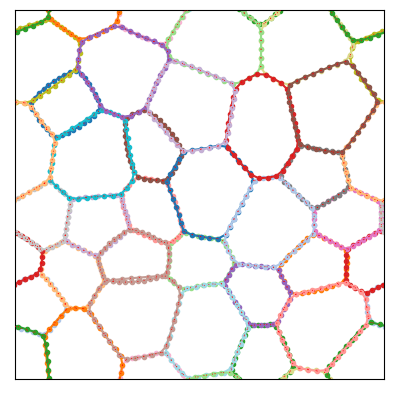

In [34]:
_ = m.draw(forces = m.getForces())
plt.show()

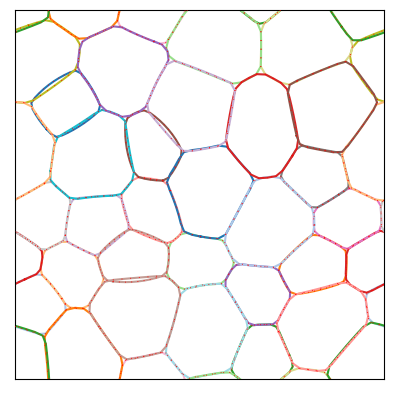

In [35]:
_ = m.draw(marker = '-', forces = m.getForces())
plt.show()

In [36]:
m.getMaxUnbalancedForce()

0.0041107086378223395

In [ ]:
m.getConstrainedForcePython(m.getForces())

In [ ]:
m.updateForceEnergy()

In [ ]:
_ = m.draw(forces = m.getForces() * 1e5)

In [ ]:
m.getConstraintViolation()

In [ ]:
f1 = m.getConstrainedForcePython(m.getForces())

In [ ]:
m.projectForce()
f2 = m.getForces()

In [ ]:
np.max(np.abs(f1 - f2))